In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [26]:
df = pd.read_csv("binance_btc_4h_2018_2026_features.csv")

In [27]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
0,2018-01-01 00:00:00,13715.65,13715.65,13155.38,13410.03,1676.20,-152.49,1676.20,-0.09,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,13410.03,0.00,0.00,0.00
1,2018-01-01 04:00:00,13434.98,13818.55,13322.15,13570.35,1302.21,-152.49,2978.42,-0.05,208771.08,...,0.10,0.02,0.08,-1.81,-0.36,-1.45,13473.33,1.20,1.19,1.20
2,2018-01-01 08:00:00,13569.98,13735.24,13001.13,13220.56,1319.76,-683.28,1658.66,-0.16,112998.44,...,-0.04,0.01,-0.05,-3.17,-0.92,-2.25,13371.54,-2.58,-2.61,-1.41
3,2018-01-01 12:00:00,13220.56,13330.00,12750.00,13247.00,1831.93,624.34,3490.60,0.10,103775.28,...,-0.13,-0.02,-0.11,-1.65,-1.07,-0.58,13321.62,0.20,0.20,-1.22
4,2018-01-01 16:00:00,13247.00,13290.65,12940.00,13240.37,1092.34,1403.42,2398.26,0.19,87915.64,...,-0.20,-0.06,-0.14,-4.16,-1.69,-2.47,13288.95,-0.05,-0.05,-1.27


In [4]:
df.tail()

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
17941,2026-03-12 20:00:00,70432.33,70734.25,70013.17,70541.34,2336.09458,1.009022e+07,3.056228e+06,-0.017325,6.367575e+05,...,0.610608,0.563296,0.047312,-4.560486,-0.322812,-4.237674,69581.959132,0.154787,0.154667,426.034170
17942,2026-03-13 00:00:00,70541.34,72000.00,70386.01,71405.75,5755.69452,1.009174e+07,3.061983e+06,-0.012415,1.256546e+06,...,0.714215,0.593480,0.120736,-0.980313,-0.454312,-0.526001,69797.870418,1.225395,1.217948,432.480166
17943,2026-03-13 04:00:00,71405.76,71672.76,71180.19,71612.22,4181.63698,1.009489e+07,3.066165e+06,0.049754,1.200380e+06,...,0.810169,0.636817,0.173351,-1.144972,-0.592444,-0.552528,69935.050524,0.289150,0.288733,434.019834
17944,2026-03-13 08:00:00,71612.23,72575.98,71385.28,72228.82,5105.15070,1.009702e+07,3.071270e+06,0.076027,1.478588e+06,...,0.945226,0.698499,0.246727,0.433384,-0.387278,0.820662,70133.367070,0.861026,0.857341,438.617885
17945,2026-03-13 12:00:00,72228.81,73593.00,72210.00,73328.73,4917.15418,1.010006e+07,3.076187e+06,0.069111,2.039994e+06,...,1.163006,0.791401,0.371606,1.300904,-0.049642,1.350546,70800.517828,1.522813,1.511335,446.820029


In [5]:
df.describe()


,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
count,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,1.794600e+04,1.794600e+04,17946.000000,1.794600e+04,1.794600e+04,...,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000,17946.000000
mean,38246.054084,38560.447053,37910.445938,38249.396376,10713.225323,5.403734e+06,1.523420e+06,0.042846,-8.769303e+04,2.068610e+06,...,0.042634,0.042458,0.000176,-1.371968,-1.371957,-0.000011,38251.598862,0.019184,0.009467,185.229760
std,32485.244129,32688.635174,32268.905198,32485.782235,14368.862866,3.702966e+06,1.405837e+06,0.127283,3.669183e+06,1.292617e+10,...,1.593816,1.507863,0.461715,12.487537,9.882487,6.827888,32483.276584,1.392070,1.395364,242.249885
min,3172.620000,3210.000000,3156.260000,3172.050000,5.887034,-7.245532e+03,-9.172363e+05,-0.407458,-6.251811e+07,-6.654058e+11,...,-11.814582,-10.322847,-3.988297,-50.715853,-45.670440,-17.731704,3246.287732,-20.496236,-22.936582,-76.345691
25%,9548.630000,9630.747500,9459.947500,9548.502500,3659.548032,1.248562e+06,-3.672053e+03,-0.044884,-5.306896e+05,-4.632543e+08,...,-0.688091,-0.651313,-0.228206,-9.236627,-7.646063,-4.599729,9600.709429,-0.470950,-0.472062,-28.795816
50%,28127.635000,28374.145000,27908.885000,28134.410000,6257.523531,5.535495e+06,1.712035e+06,0.041658,-6.589064e+03,5.126519e+06,...,0.046090,0.047809,-0.005452,-1.800241,-1.549046,-0.686334,28131.222590,0.019369,0.019367,109.801246
75%,59414.880000,59932.282500,58866.500000,59416.972500,11361.605046,9.260156e+06,3.058933e+06,0.126877,4.952246e+05,6.559702e+08,...,0.854289,0.827565,0.222171,6.007576,4.751636,3.805859,59273.239605,0.513637,0.512322,343.078595
max,125410.800000,126199.630000,124800.000000,125410.810000,284711.694213,1.011630e+07,3.422245e+06,0.521882,7.245077e+07,1.756758e+11,...,6.341956,5.502219,3.008708,59.658646,36.224820,44.601687,123121.777258,14.749019,13.757711,835.201562


In [6]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [7]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
0,2018-01-01 00:00:00,13715.65,13715.65,13155.38,13410.03,1676.20,-152.49,1676.20,-0.09,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,13410.03,0.00,0.00,0.00
1,2018-01-01 04:00:00,13434.98,13818.55,13322.15,13570.35,1302.21,-152.49,2978.42,-0.05,208771.08,...,0.10,0.02,0.08,-1.81,-0.36,-1.45,13473.33,1.20,1.19,1.20
2,2018-01-01 08:00:00,13569.98,13735.24,13001.13,13220.56,1319.76,-683.28,1658.66,-0.16,112998.44,...,-0.04,0.01,-0.05,-3.17,-0.92,-2.25,13371.54,-2.58,-2.61,-1.41
3,2018-01-01 12:00:00,13220.56,13330.00,12750.00,13247.00,1831.93,624.34,3490.60,0.10,103775.28,...,-0.13,-0.02,-0.11,-1.65,-1.07,-0.58,13321.62,0.20,0.20,-1.22
4,2018-01-01 16:00:00,13247.00,13290.65,12940.00,13240.37,1092.34,1403.42,2398.26,0.19,87915.64,...,-0.20,-0.06,-0.14,-4.16,-1.69,-2.47,13288.95,-0.05,-0.05,-1.27


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17946 entries, 0 to 17945
Data columns (total 92 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  17946 non-null  object 
 1   Open                       17946 non-null  float64
 2   High                       17946 non-null  float64
 3   Low                        17946 non-null  float64
 4   Close                      17946 non-null  float64
 5   Volume                     17946 non-null  float64
 6   volume_adi                 17946 non-null  float64
 7   volume_obv                 17946 non-null  float64
 8   volume_cmf                 17946 non-null  float64
 9   volume_fi                  17946 non-null  float64
 10  volume_em                  17946 non-null  float64
 11  volume_sma_em              17946 non-null  float64
 12  volume_vpt                 17946 non-null  float64
 13  volume_vwap                17946 non-null  flo

In [9]:
# istatiksel filtreleme (korelasyon matrisi) -> tahmin edilmesi istenen değer ile diğer değişkenlerin bağlantısı 
# en yüksek olanları seçer diğerlerini drop ederiz.

# algoritmik puanlama (Tree-based feature importance) -> korelasyon her zaman tahmin edilmesi istenen değer 
# ile diğer değişkenlerin bağlantısını doğru bulamayabilir.
# ham veri setini LightGBM veya Random Forest içerisine veririz.

# 1.ilk sırada EDA yapılarak modele vermeden önce elimizde ne olduğuna bakılmalı

# 2. Data cleaning & preprocessing yapılmalı  ( preprocessing değerler arasındaki devasa farkları sayıları küçülterek
# önem sırasına koymaya yarar.

# 3. Feature Engineering yapılmalı 

# 4. Feature Selection yapılmalı ( birbirinin kopyası olan satırlardan birisi silinir, hedef değişkenle 
# en alakalı satırlar bırakılır. korelasyonu 0.9 veya -0.9 üzeri olanlardan silinecekler arasında
# hedef değişkenle en alakalı olan bırakılır diğer satır silinir.)

# Train test split

# Model Training & Hyperparameter Tuning 

# Backtesting & Evaluation(modelin hiç görmediği test verisiyle sonuclara bakılır)

In [10]:
df[df.corr(numeric_only=True)>0.9]

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
corr = df.corr(numeric_only=True).abs()

In [12]:
plt.figure(figsize=(20,15))

<Figure size 2000x1500 with 0 Axes>

<Figure size 2000x1500 with 0 Axes>

<Axes: >

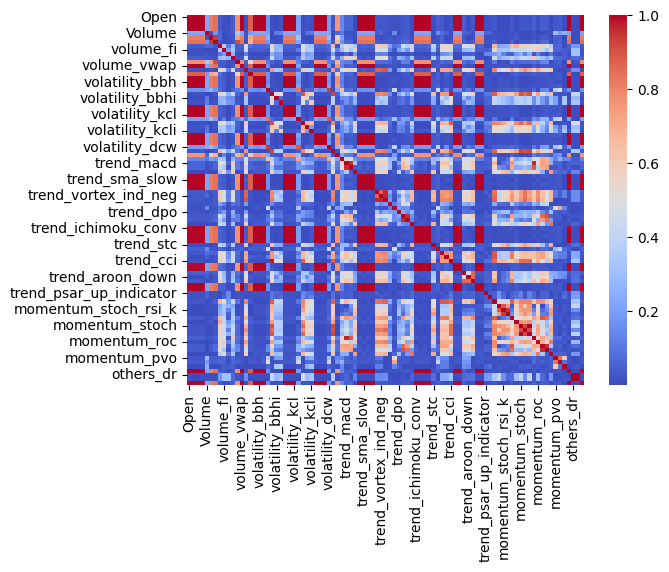

In [13]:
sns.heatmap(corr, annot=False, cmap="coolwarm")

In [14]:
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [15]:
corr

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
Open,1.00,1.00,1.00,1.00,0.22,0.81,0.84,0.03,0.02,0.00,...,0.04,0.04,0.00,0.03,0.03,0.00,1.00,0.01,0.01,1.00
High,1.00,1.00,1.00,1.00,0.22,0.81,0.84,0.03,0.01,0.01,...,0.04,0.04,0.00,0.02,0.03,0.00,1.00,0.00,0.00,1.00
Low,1.00,1.00,1.00,1.00,0.22,0.81,0.84,0.03,0.01,0.01,...,0.04,0.04,0.00,0.03,0.03,0.00,1.00,0.00,0.00,1.00
Close,1.00,1.00,1.00,1.00,0.22,0.81,0.84,0.03,0.01,0.01,...,0.04,0.04,0.00,0.03,0.03,0.00,1.00,0.00,0.01,1.00
Volume,0.22,0.22,0.22,0.22,1.00,0.02,0.18,0.06,0.00,0.02,...,0.00,0.00,0.01,0.30,0.20,0.25,0.22,0.00,0.01,0.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
momentum_pvo_hist,0.00,0.00,0.00,0.00,0.25,0.00,0.00,0.01,0.04,0.04,...,0.00,0.02,0.04,0.62,0.09,1.00,0.00,0.02,0.02,0.00
momentum_kama,1.00,1.00,1.00,1.00,0.22,0.81,0.84,0.04,0.03,0.00,...,0.03,0.03,0.01,0.02,0.03,0.00,1.00,0.01,0.00,1.00
others_dr,0.01,0.00,0.00,0.00,0.00,0.00,0.01,0.18,0.31,0.30,...,0.07,0.02,0.18,0.00,0.01,0.02,0.01,1.00,1.00,0.00
others_dlr,0.01,0.00,0.00,0.01,0.01,0.00,0.01,0.18,0.31,0.30,...,0.07,0.02,0.18,0.01,0.00,0.02,0.00,1.00,1.00,0.01


In [30]:
corr_matrix = df.corr(numeric_only=True)

In [31]:
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

In [32]:
upper_triangle = corr_matrix.where(mask)

In [34]:
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.90)]

In [35]:
df_cleaned = df.drop(columns=to_drop)

In [37]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
0,2018-01-01 00:00:00,13715.65,13715.65,13155.38,13410.03,1676.20,-152.49,1676.20,-0.09,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,13410.03,0.00,0.00,0.00
1,2018-01-01 04:00:00,13434.98,13818.55,13322.15,13570.35,1302.21,-152.49,2978.42,-0.05,208771.08,...,0.10,0.02,0.08,-1.81,-0.36,-1.45,13473.33,1.20,1.19,1.20
2,2018-01-01 08:00:00,13569.98,13735.24,13001.13,13220.56,1319.76,-683.28,1658.66,-0.16,112998.44,...,-0.04,0.01,-0.05,-3.17,-0.92,-2.25,13371.54,-2.58,-2.61,-1.41
3,2018-01-01 12:00:00,13220.56,13330.00,12750.00,13247.00,1831.93,624.34,3490.60,0.10,103775.28,...,-0.13,-0.02,-0.11,-1.65,-1.07,-0.58,13321.62,0.20,0.20,-1.22
4,2018-01-01 16:00:00,13247.00,13290.65,12940.00,13240.37,1092.34,1403.42,2398.26,0.19,87915.64,...,-0.20,-0.06,-0.14,-4.16,-1.69,-2.47,13288.95,-0.05,-0.05,-1.27


In [38]:
df_cleaned

,Timestamp,Open,Volume,volume_adi,volume_cmf,volume_fi,volume_em,volume_sma_em,volume_mfi,volume_nvi,...,momentum_stoch_rsi_k,momentum_tsi,momentum_uo,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr
0,2018-01-01 00:00:00,13715.65,1676.20,-152.49,-0.09,0.00,0.00,0.00,50.00,1000.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2018-01-01 04:00:00,13434.98,1302.21,-152.49,-0.05,208771.08,5139865723.35,5139865723.35,100.00,1011.96,...,0.00,100.00,23.49,0.00,0.10,0.08,-1.81,-0.36,-1.45,1.20
2,2018-01-01 08:00:00,13569.98,1319.76,-683.28,-0.16,112998.44,-11245363226.94,-3052748751.79,50.13,1011.96,...,0.00,95.27,26.11,0.00,-0.04,-0.05,-3.17,-0.92,-2.25,-2.58
3,2018-01-01 12:00:00,13220.56,1831.93,624.34,0.10,103775.28,-10390515597.60,-5498671033.73,29.82,1011.96,...,0.00,91.58,40.69,0.00,-0.13,-0.11,-1.65,-1.07,-0.58,0.20
4,2018-01-01 16:00:00,13247.00,1092.34,1403.42,0.19,87915.64,2417999719.12,-3519503345.51,43.52,1011.45,...,0.00,88.55,46.48,0.00,-0.20,-0.14,-4.16,-1.69,-2.47,-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17941,2026-03-12 20:00:00,70432.33,2336.09,10090223.10,-0.02,636757.50,6287896391.59,-1014930468.40,46.73,103445.76,...,0.49,11.41,53.72,0.85,0.61,0.05,-4.56,-0.32,-4.24,0.15
17942,2026-03-13 00:00:00,70541.34,5755.69,10091740.45,-0.01,1256546.42,22974359262.03,122370499.61,56.45,103445.76,...,0.71,13.46,59.31,2.67,0.71,0.12,-0.98,-0.45,-0.53,1.23
17943,2026-03-13 04:00:00,71405.76,4181.64,10094894.19,0.05,1200380.15,2750126767.34,1818825119.74,63.00,103744.87,...,0.92,15.50,65.01,2.82,0.81,0.17,-1.14,-0.59,-0.55,0.29
17944,2026-03-13 08:00:00,71612.23,5105.15,10097022.43,0.08,1478588.12,12924836058.22,2857408557.08,70.81,103744.87,...,1.00,18.27,64.67,4.42,0.95,0.25,0.43,-0.39,0.82,0.86


In [39]:
df_cleaned['Target'] = df['Close'].shift(-1)

In [40]:
df_cleaned.tail()

,Timestamp,Open,Volume,volume_adi,volume_cmf,volume_fi,volume_em,volume_sma_em,volume_mfi,volume_nvi,...,momentum_tsi,momentum_uo,momentum_roc,momentum_ppo,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,others_dr,Target
17941,2026-03-12 20:00:00,70432.33,2336.09,10090223.10,-0.02,636757.50,6287896391.59,-1014930468.40,46.73,103445.76,...,11.41,53.72,0.85,0.61,0.05,-4.56,-0.32,-4.24,0.15,71405.75
17942,2026-03-13 00:00:00,70541.34,5755.69,10091740.45,-0.01,1256546.42,22974359262.03,122370499.61,56.45,103445.76,...,13.46,59.31,2.67,0.71,0.12,-0.98,-0.45,-0.53,1.23,71612.22
17943,2026-03-13 04:00:00,71405.76,4181.64,10094894.19,0.05,1200380.15,2750126767.34,1818825119.74,63.00,103744.87,...,15.50,65.01,2.82,0.81,0.17,-1.14,-0.59,-0.55,0.29,72228.82
17944,2026-03-13 08:00:00,71612.23,5105.15,10097022.43,0.08,1478588.12,12924836058.22,2857408557.08,70.81,103744.87,...,18.27,64.67,4.42,0.95,0.25,0.43,-0.39,0.82,0.86,73328.73
17945,2026-03-13 12:00:00,72228.81,4917.15,10100060.40,0.07,2039993.68,25900412380.40,4667549599.74,71.77,105324.71,...,22.40,67.41,4.42,1.16,0.37,1.30,-0.05,1.35,1.52,NaN


In [41]:
df_cleaned['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

<Axes: ylabel='Close'>

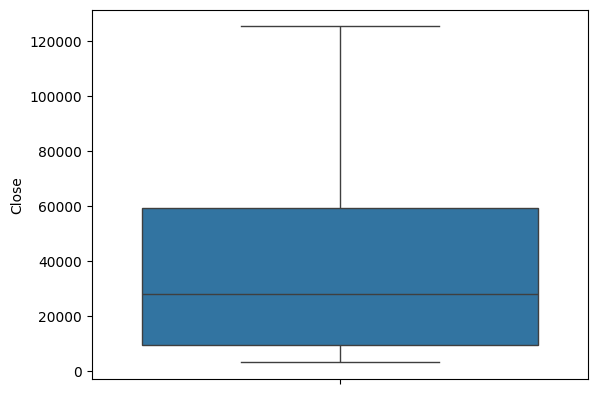

In [42]:
sns.boxplot(data=df, y="Close")

In [43]:
df.describe()

,Open,High,Low,Close,Volume,volume_adi,volume_obv,volume_cmf,volume_fi,volume_em,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
count,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,...,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00,17946.00
mean,38246.05,38560.45,37910.45,38249.40,10713.23,5403734.11,1523419.58,0.04,-87693.03,2068609.52,...,0.04,0.04,0.00,-1.37,-1.37,-0.00,38251.60,0.02,0.01,185.23
std,32485.24,32688.64,32268.91,32485.78,14368.86,3702966.28,1405837.25,0.13,3669182.90,12926171372.28,...,1.59,1.51,0.46,12.49,9.88,6.83,32483.28,1.39,1.40,242.25
min,3172.62,3210.00,3156.26,3172.05,5.89,-7245.53,-917236.34,-0.41,-62518114.44,-665405839341.19,...,-11.81,-10.32,-3.99,-50.72,-45.67,-17.73,3246.29,-20.50,-22.94,-76.35
25%,9548.63,9630.75,9459.95,9548.50,3659.55,1248562.31,-3672.05,-0.04,-530689.55,-463254312.06,...,-0.69,-0.65,-0.23,-9.24,-7.65,-4.60,9600.71,-0.47,-0.47,-28.80
50%,28127.63,28374.15,27908.89,28134.41,6257.52,5535494.62,1712034.85,0.04,-6589.06,5126518.82,...,0.05,0.05,-0.01,-1.80,-1.55,-0.69,28131.22,0.02,0.02,109.80
75%,59414.88,59932.28,58866.50,59416.97,11361.61,9260156.34,3058933.08,0.13,495224.64,655970223.15,...,0.85,0.83,0.22,6.01,4.75,3.81,59273.24,0.51,0.51,343.08
max,125410.80,126199.63,124800.00,125410.81,284711.69,10116302.91,3422245.03,0.52,72450766.89,175675752923.77,...,6.34,5.50,3.01,59.66,36.22,44.60,123121.78,14.75,13.76,835.20


In [44]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17946 entries, 0 to 17945
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  17946 non-null  object 
 1   Open                       17946 non-null  float64
 2   Volume                     17946 non-null  float64
 3   volume_adi                 17946 non-null  float64
 4   volume_cmf                 17946 non-null  float64
 5   volume_fi                  17946 non-null  float64
 6   volume_em                  17946 non-null  float64
 7   volume_sma_em              17946 non-null  float64
 8   volume_mfi                 17946 non-null  float64
 9   volume_nvi                 17946 non-null  float64
 10  volatility_bbw             17946 non-null  float64
 11  volatility_bbp             17946 non-null  float64
 12  volatility_bbhi            17946 non-null  float64
 13  volatility_bbli            17946 non-null  flo

In [45]:
predict_data = df_cleaned.iloc[-1:].copy()

In [46]:
train_data = df_cleaned.iloc[:-1].copy()

In [47]:
train_data.dropna(subset=['Target'], inplace=True)

In [48]:
from sklearn.preprocessing import StandardScaler # ani değerler olacağı için minmaxscaler yerine kullanılacak

In [49]:
scaler = StandardScaler()

In [50]:
train_data.set_index('Timestamp', inplace=True)
predict_data.set_index('Timestamp', inplace=True)

In [51]:
X_train = train_data.drop(columns=['Target'])
y_train = train_data['Target']

X_train_scaled = scaler.fit_transform(X_train)

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import r2_score, accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV

In [53]:
X = train_data.drop(columns = ["Target"])
y = train_data["Target"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state = 15)

In [55]:
from sklearn.model_selection import RandomizedSearchCV

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "SVC": SVC(probability=True)
}

param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2']
    },
    "Random Forest": {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    "XGBoost": {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    "SVC": {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
}

best_models = []

for model_name in models.keys():
    print(f"{model_name} optimize ediliyor...")
    
    random_search = RandomizedSearchCV(
        estimator=models[model_name],
        param_distributions=param_grids[model_name],
        n_iter=10,          
        scoring='precision',
        cv=3,               
        n_jobs=-1,     
        random_state=42,
        verbose=0
    )
    

    random_search.fit(X_train_scaled, y_train)
    

    best_models.append({
        "Model": model_name,
        "En İyi Precision": random_search.best_score_,
        "En İyi Parametreler": random_search.best_params_
    })

optimization_results = pd.DataFrame(best_models).sort_values(by="En İyi Precision", ascending=False)
print(optimization_results)

Logistic Regression optimize ediliyor...


ValueError: Found input variables with inconsistent numbers of samples: [17945, 14356]